# **Fourth Task: FairClean Pipeline on the Adult Dataset on a Logistic Regression Model.**

#1. Import Libraries
This section loads the core Python libraries used throughout the FairClean pipeline.  
Pandas and NumPy handle data manipulation and numerical operations. Scikit‑learn provides the tools for splitting the dataset, scaling features, and training the Logistic Regression model. These imports prepare the environment for data cleaning, fairness diagnostics, and model evaluation.

In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

2. Load Adult Dataset(Pre-processed)

The same preprocessed Adult dataset used for the Decision Tree model, in FairCleanAdultModel1.ipynb is used her as well to ensure adequate comparison of both models performance and behaviours.

In [4]:
df = pd.read_csv("/content/drive/MyDrive/adult-preproc.csv").reset_index(drop=True)

#3. Verify Target and Sensitive Attribute
This section ensures that the target variable and the sensitive attribute are correctly formatted before running any fairness analysis.  
The Adult dataset already encodes the income label and gender as binary values, so the only required steps are removing rows with missing values and renaming the gender column for consistency. Renaming sex to sex_bin keeps the notation uniform across all models and fairness tests. This prepares the dataset for one‑hot encoding and the FairClean diagnostics that follow.

In [5]:
# income is already 0/1
# sex is already 0/1 (1 = Male, 0 = Female)

df = df.dropna(subset=["income", "sex"]).reset_index(drop=True)

# Rename sex → sex_bin for consistency
df = df.rename(columns={"sex": "sex_bin"})

#4. One-Hot Encode Categoricals
This section converts the remaining categorical variables into numerical format using one‑hot encoding.  
Machine‑learning models such as Logistic Regression cannot directly interpret text labels, so each category is transformed into its own binary column. The first category in each group is dropped to avoid redundancy and multicollinearity. Numerical features are kept unchanged. This step produces a fully numeric dataset that is ready for model training and fairness diagnostics.

In [6]:
categorical_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "native-country"
]

numeric_cols = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "pc1", "pc2", "pc3", "pc4", "pc5", "pc6"
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df = df.reset_index(drop=True)

#5. Train Logistic Regression Model
This function trains a Logistic Regression model on the cleaned Adult dataset.  
The features and target variable are separated, and the data is split into training and testing sets using a stratified split to preserve the original class distribution. A StandardScaler is applied so that all numerical features share a similar range, which helps Logistic Regression learn stable coefficients. The model is trained with balanced class weights to reduce the impact of class imbalance. If sample weights are provided, they are applied during training to support FairClean’s reweighting step. The function returns the trained model, the data splits, and the fitted scaler for later use in fairness diagnostics.

In [7]:
def train_model(df, sample_weight=None):
    X = df.drop(columns=["income"])
    y = df["income"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(max_iter=500, class_weight="balanced")

    if sample_weight is not None:
        model.fit(X_train_scaled, y_train, sample_weight=sample_weight.loc[y_train.index])
    else:
        model.fit(X_train_scaled, y_train)

    return model, X_train, X_test, y_train, y_test, scaler

#6. Fairness Metrics
This function calculates group‑level fairness metrics for the Logistic Regression model.  
The model’s predictions are generated for the full dataset using the fitted scaler. These predictions are then compared across the binary gender groups. The positive prediction rate is computed separately for males and females, and two standard fairness indicators are derived:

* Gap: the difference in positive prediction rates between males and females.

* Ratio: the proportion of the female prediction rate relative to the male rate.

These metrics provide a simple measure of demographic parity and form the baseline for evaluating how FairClean affects model fairness.

In [8]:
def compute_fairness(df, model, scaler):
    X = df.drop(columns=["income"])
    X_scaled = scaler.transform(X)
    preds = model.predict(X_scaled)

    tmp = df.copy()
    tmp["pred"] = preds

    rates = tmp.groupby("sex_bin")["pred"].mean().to_dict()
    gap = rates[1] - rates[0]
    ratio = rates[0] / rates[1] if rates[1] > 0 else np.nan

    return {"rates": rates, "gap": gap, "ratio": ratio}

#7. Vectorised Counterfactual Generation
This section implements fast, vectorised counterfactual tests to identify rows where the model’s prediction changes when the sensitive attribute is altered.  
The attribute‑level counterfactual test flips the gender value (sex_bin) for every row and checks whether the Logistic Regression model produces a different prediction. Because the operation is vectorised, the entire dataset is processed in a single batch, making the test efficient even for large datasets. The causal counterfactual function currently mirrors the attribute test, maintaining a consistent structure in the pipeline and allowing a different causal mechanism to be added later without changing the rest of the code.

In [9]:
def attribute_cf_fast(df, model, scaler, X_cols):
    X = df[X_cols].copy()
    factual = model.predict(scaler.transform(X))

    X_cf = X.copy()
    X_cf["sex_bin"] = 1 - X_cf["sex_bin"]

    cf = model.predict(scaler.transform(X_cf))
    return np.where(factual != cf)[0].tolist()

def causal_cf_fast(df, model, scaler, X_cols):
    return attribute_cf_fast(df, model, scaler, X_cols)

#8. Structural Uplift Rules(Adult)
This function applies a set of structural uplift transformations to test how stable the model’s predictions are under systematically improved socio‑economic conditions.  
The idea is to simulate a “best‑case scenario” for each individual by increasing key features to their most favourable values. Continuous variables such as education level, capital gain, capital loss, and working hours are set to their maximum observed values. For one‑hot encoded categories (occupation, workclass, and marital status), all categories are reset and a single representative category is activated. These transformations create a counterfactual version of the dataset where structural advantages are maximised.

The model’s predictions are then compared before and after the uplift. Rows where the prediction changes are flagged as structurally unstable. This identifies individuals whose predicted outcomes are highly sensitive to improvements in socio‑economic features, forming the basis for FairClean’s structural uplift mitigation step.

In [10]:
def structural_cf_fast(df, model, scaler, X_cols):
    X = df[X_cols].copy()
    factual = model.predict(scaler.transform(X))

    X_cf = X.copy()

    # EDUCATION UPLIFT
    if "education-num" in X_cf.columns:
        X_cf["education-num"] = X_cf["education-num"].max()

    # CAPITAL GAIN UPLIFT
    if "capital-gain" in X_cf.columns:
        X_cf["capital-gain"] = X_cf["capital-gain"].max()

    # CAPITAL LOSS UPLIFT
    if "capital-loss" in X_cf.columns:
        X_cf["capital-loss"] = X_cf["capital-loss"].max()

    # HOURS PER WEEK UPLIFT
    if "hours-per-week" in X_cf.columns:
        X_cf["hours-per-week"] = X_cf["hours-per-week"].max()

    # OCCUPATION UPLIFT
    occ_cols = [c for c in X_cf.columns if c.startswith("occupation_")]
    if occ_cols:
        X_cf[occ_cols] = 0
        X_cf[occ_cols[0]] = 1

    # WORKCLASS UPLIFT
    wc_cols = [c for c in X_cf.columns if c.startswith("workclass_")]
    if wc_cols:
        X_cf[wc_cols] = 0
        X_cf[wc_cols[0]] = 1

    # MARITAL STATUS UPLIFT
    ms_cols = [c for c in X_cf.columns if c.startswith("marital-status_")]
    if ms_cols:
        X_cf[ms_cols] = 0
        X_cf[ms_cols[0]] = 1

    cf = model.predict(scaler.transform(X_cf))
    unstable = np.where(factual != cf)[0].tolist()
    return unstable

#9. Hybrid Mitigation and Cleaning Logs
This function applies FairClean’s hybrid mitigation strategy by combining row removal and reweighting based on the three counterfactual tests.  
Rows that fail either the attribute‑level or causal counterfactual tests are removed entirely, as these represent direct or causal unfairness. Rows that fail the structural uplift test are retained but assigned a lower weight, reducing their influence during model training while preserving valuable information.

A cleaning log is generated to record the outcome for every original row, including whether it failed each test, whether it was removed, and whether it was reweighted. This log provides full transparency and traceability, allowing the mitigation process to be audited and reported clearly in the results section.

In [11]:
def mitigate_fast(df, unstable_attr, unstable_causal, unstable_struct):
    remove_ids = sorted(set(unstable_attr) | set(unstable_causal))

    df_clean = df.loc[~df.index.isin(remove_ids)].copy().reset_index(drop=True)
    df_clean["weight"] = 1.0

    struct_mask = df.index.isin(unstable_struct)
    struct_original = df.index[struct_mask]
    struct_new = df_clean.index[df_clean.index.isin(struct_original)]

    df_clean.loc[struct_new, "weight"] = 0.5

    cleaning_log = pd.DataFrame({
        "row_index": df.index,
        "attribute_unfair": df.index.isin(unstable_attr),
        "causal_unfair": df.index.isin(unstable_causal),
        "structural_unfair": df.index.isin(unstable_struct),
        "removed": df.index.isin(remove_ids),
        "reweighted": df.index.isin(unstable_struct)
    })

    return df_clean, len(remove_ids), len(struct_new), cleaning_log

#10. Run FairClean
This section executes the full FairClean pipeline on the Adult dataset using Logistic Regression.  
The baseline model is trained first, and its fairness metrics are recorded to establish a reference point. The three counterfactual tests—attribute, causal, and structural—are then applied to identify rows where the model’s predictions are unstable or unfair. These results feed into the hybrid mitigation step, which removes rows failing direct or causal fairness tests and reweights rows failing structural uplift.

A new Logistic Regression model is trained on the cleaned dataset using the assigned sample weights. Fairness metrics are computed again to assess how the mitigation affected demographic parity. All key outputs—including the number of unstable rows, removed rows, reweighted rows, and fairness scores before and after cleaning—are stored in a results dictionary for reporting and analysis.

In [12]:
baseline_model, X_train, X_test, y_train, y_test, scaler = train_model(df)
baseline_fairness = compute_fairness(df, baseline_model, scaler)

unstable_attr = attribute_cf_fast(df, baseline_model, scaler, X_train.columns)
unstable_causal = causal_cf_fast(df, baseline_model, scaler, X_train.columns)
unstable_struct = structural_cf_fast(df, baseline_model, scaler, X_train.columns)

df_clean, removed_count, reweighted_count, cleaning_log = mitigate_fast(
    df, unstable_attr, unstable_causal, unstable_struct
)

clean_model, X_train_clean, X_test_clean, y_train_clean, y_test_clean, scaler_clean = train_model(
    df_clean.drop(columns=["weight"]),
    sample_weight=df_clean["weight"]
)

clean_fairness = compute_fairness(df_clean.drop(columns=["weight"]), clean_model, scaler_clean)

results = {
    "baseline_fairness": baseline_fairness,
    "unstable_attr": len(unstable_attr),
    "unstable_causal": len(unstable_causal),
    "unstable_struct": len(unstable_struct),
    "removed_rows": removed_count,
    "reweighted_rows": reweighted_count,
    "cleaned_fairness": clean_fairness,
}

results

{'baseline_fairness': {'rates': {0: 0.13407855731225296,
   1: 0.46483920367534454},
  'gap': 0.33076064636309155,
  'ratio': 0.28844072585129205},
 'unstable_attr': 6087,
 'unstable_causal': 6087,
 'unstable_struct': 31494,
 'removed_rows': 6087,
 'reweighted_rows': 27586,
 'cleaned_fairness': {'rates': {0: 0.1407118285260651, 1: 0.38337132313035927},
  'gap': 0.24265949460429417,
  'ratio': 0.36703796042203785}}

#11. Display Removed Rows

In [13]:
removed_rows_df = df.loc[cleaning_log["removed"]]
removed_rows_df

,age,fnlwgt,education-num,sex_bin,capital-gain,capital-loss,hours-per-week,income,pc1,pc2,...,relationship_1,relationship_2,relationship_3,relationship_4,relationship_5,race_1,race_2,race_3,race_4,native-country_1
18,0,0.011232,0.400000,1,0.000000,0.0,0.500000,0,4.951189,-0.771826,...,False,False,False,False,False,False,False,False,True,True
19,0,0.189356,0.866667,0,0.000000,0.0,0.448980,1,-3.847872,-0.674573,...,False,False,False,True,False,False,False,False,True,True
27,0,0.113608,0.600000,1,0.000000,0.0,0.602041,1,8.269280,-0.998064,...,False,False,False,False,False,True,False,False,False,False
28,0,0.240154,0.533333,1,0.000000,0.0,0.806122,0,-4.022662,-2.171365,...,True,False,False,False,False,False,False,False,True,True
29,0,0.122508,0.533333,1,0.000000,0.0,0.397959,0,-4.980353,-1.817614,...,False,False,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48823,0,0.047652,0.533333,1,0.000000,0.0,0.397959,0,-4.980348,-1.817714,...,False,False,False,False,False,False,False,False,True,True
48831,0,0.184888,0.533333,1,0.000000,0.0,0.397959,0,-6.973773,-1.805578,...,False,False,False,False,False,False,False,False,True,True
48832,0,0.052365,0.533333,1,0.000000,0.0,0.479592,0,4.986585,-1.879299,...,False,False,False,False,False,False,False,False,True,True
48837,0,0.137428,0.800000,0,0.000000,0.0,0.357143,0,2.966372,-2.452184,...,True,False,False,False,False,False,False,False,True,True


#12. Export/Save FairCleaned Dataset

# **Visualisation**

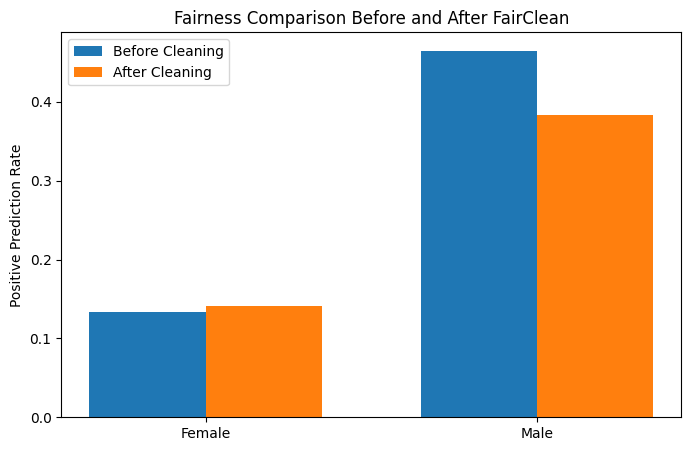

In [14]:
import matplotlib.pyplot as plt

before_f = baseline_fairness["rates"][0]
before_m = baseline_fairness["rates"][1]
after_f = clean_fairness["rates"][0]
after_m = clean_fairness["rates"][1]

labels = ["Female", "Male"]
before = [before_f, before_m]
after = [after_f, after_m]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, before, width, label="Before Cleaning")
plt.bar(x + width/2, after, width, label="After Cleaning")

plt.xticks(x, labels)
plt.ylabel("Positive Prediction Rate")
plt.title("Fairness Comparison Before and After FairClean")
plt.legend()
plt.show()

This indicates some improvement in fairness, though some disparity still remains.

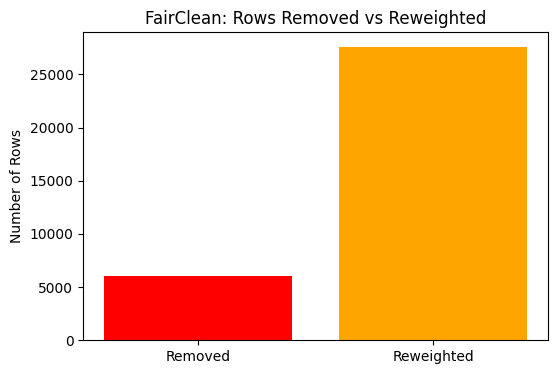

In [15]:
plt.figure(figsize=(6,4))
plt.bar(["Removed", "Reweighted"], [removed_count, reweighted_count], color=["red", "orange"])
plt.ylabel("Number of Rows")
plt.title("FairClean: Rows Removed vs Reweighted")
plt.show()